# Causal discovery on ADNI multimodal data: tutorial

This notebook walks through the analysis step by step with the `adni_fci` package in this repository. It replaces the old per-setting notebooks (kept in `archive/notebooks/`). Every analysis setting is defined once in `adni_fci/settings.py`, and the same code runs all of them.

**Pipeline**

1. **Cohort**: baseline ADNI subjects with MRI volumes, fluid biomarkers (plasma or CSF) and/or tau PET within ±3 months of the MRI, plus demographics, APOE and cognition.
2. **Preprocessing**: Yeo-Johnson for skewed variables, then z-scoring.
3. **Background knowledge**: demographics are exogenous and cognition is downstream.
4. **Bootstrapped FCI**: FCI with the kernel CI test (KCI) on bootstrap resamples, with random variable order.
5. **Summaries**: edge frequencies, PAG figures, sensitivity to α, separating sets, and the analysis stratified by diagnosis.

Full runs are easiest from the command line (`python run_analysis.py main`, see section 10). Here `QUICK = True` uses 28 bootstraps instead of 200, so the notebook runs in about 15 minutes on 14 cores. The frequencies below are therefore noisier than in a full run.

In [1]:
import warnings
from dataclasses import replace

import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")  # harmless tqdm notice when causal-learn loads

from adni_fci import (EDGE_MEANINGS, PRESETS, RESULTS_DIR, build_cohort, compare_edge_tables, compare_settings,
                      edge_frequencies, format_edges, plot_background_knowledge, plot_distributions,
                      plot_endpoint_heatmaps, plot_sepsets, preprocess, run_bootstrap_fci, run_setting,
                      run_stratified, sepset_summary, show_pag)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 140)

QUICK = True  # few bootstraps (minutes); set to False to reproduce the full analysis (hours)
N_JOBS = -1   # parallel workers, -1 = all cores

## 1. Settings

A *setting* bundles every choice that used to need a separate notebook: which variables enter the graph, the data release, the CI test, α, the number of bootstraps and the background-knowledge rules. The presets are:

In [2]:
pd.DataFrame([{"setting": s.name, "CI test": s.ci_test, "variables": len(s.variables), "description": s.description}
              for s in PRESETS.values()]).set_index("setting")

,CI test,variables,description
setting,,,
main,kci,12,"Plasma Aβ42/40, pTau217, NfL, GFAP + ICV and hippocampus + ADAS-Cog13 + demographics, KCI test."
fisherz,fisherz,12,Main setting with the linear-Gaussian Fisher-z test instead of KCI.
csf,kci,10,CSF Aβ42/40 and pTau181 in place of the plasma panel.
tau_pet,kci,12,Tau PET (flortaucipir meta-temporal SUVR) in place of plasma pTau217.
cognition,kci,15,"Four cognitive outcomes (ADAS-Cog13, MMSE, TMT-B, MoCA); no edges among them."
cognition_amygdala,kci,16,Cognition setting with amygdala volume added.
plasma_assays,kci,13,"Mar 2026 plasma release: NfL/GFAP from Quanterix or Fujirebio, with the assay platform as an exogenous covariate."
no_mri_to_plasma,kci,12,Main setting with MRI volumes forbidden from causing fluid biomarkers.


We use the main setting (the one in the AAIC abstract). Any field can be changed with `dataclasses.replace` without editing the presets. In quick mode we lower the number of bootstraps and give the run its own name, so it cannot overwrite a full run in `results/main/`.

In [12]:
setting = PRESETS["fisherz"]
if QUICK:
    setting = replace(setting, name="tutorial_quick", n_bootstraps=28, n_bootstraps_stratified=14)

pd.Series({k: v for k, v in setting.to_dict().items() if k != "description"}, name=setting.name).to_frame()

,tutorial_quick
name,tutorial_quick
mri,"(Intracranial Volume, Hippocampus)"
biomarkers,"(AB42_AB40_ratio, pT217_F, NfL_Q, GFAP_Q)"
cognitive,"(TOTAL13,)"
demographics,"(PTGENDER, PTEDUCAT, AGE, APOE4_0, APOE4_1)"
covariates,()
plasma_release,2025
match_window_months,3
tau_tracer,FTP
ci_test,fisherz


## 2. Cohort

`build_cohort` loads only the tables the setting needs. For each subject it keeps the earliest MRI that has a fluid-biomarker sample within ±3 months. Demographics, APOE and cognition are joined by RID, and the baseline diagnosis is attached for the stratified analysis. Subjects missing any analysis variable are dropped.

In [13]:
cohort = build_cohort(setting)
print(f"{len(cohort)} subjects")
cohort["DX_GROUP"].value_counts()

560 subjects


DX_GROUP
CN     295
MCI    196
AD      69
Name: count, dtype: int64

In [14]:
cohort[setting.variables].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Intracranial Volume,560.0,1497688.79,244821.28,1087395.02,1366715.13,1466669.09,1589701.67,4450371.17
Hippocampus,560.0,7237.16,1086.16,4006.20,6524.10,7258.75,7961.38,10713.30
AB42_AB40_ratio,560.0,0.09,0.03,0.01,0.08,0.09,0.10,0.66
pT217_F,560.0,0.29,0.31,0.03,0.09,0.16,0.39,2.43
NfL_Q,560.0,21.49,13.80,5.40,13.60,18.90,26.12,208.00
GFAP_Q,560.0,174.02,100.83,30.60,101.25,150.20,219.95,728.80
TOTAL13,560.0,14.29,9.19,0.00,7.33,11.84,19.42,47.33
PTGENDER,560.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
PTEDUCAT,560.0,16.28,2.45,8.00,15.00,16.00,18.00,20.00
AGE,560.0,72.54,7.46,50.00,67.00,73.00,78.00,91.00


## 3. Preprocessing

KCI uses Gaussian kernels whose width is set from the data, so heavy tails and scale differences matter. Continuous variables with |skew| > 1 are Yeo-Johnson transformed, then all continuous variables are z-scored. Binary variables (sex, APOE4 indicators) stay 0/1.

In [15]:
X, report = preprocess(cohort, setting.variables)
report.round(2)

,type,skew_before,yeo_johnson,skew_after
variable,,,,
Intracranial Volume,continuous,4.75,True,-0.07
Hippocampus,continuous,-0.08,False,-0.08
AB42_AB40_ratio,continuous,12.99,True,-0.70
pT217_F,continuous,2.34,True,0.39
NfL_Q,continuous,5.51,True,-0.01
GFAP_Q,continuous,1.53,True,-0.00
TOTAL13,continuous,1.04,True,-0.01
PTGENDER,binary,NaN,False,NaN
PTEDUCAT,continuous,-0.37,False,-0.37


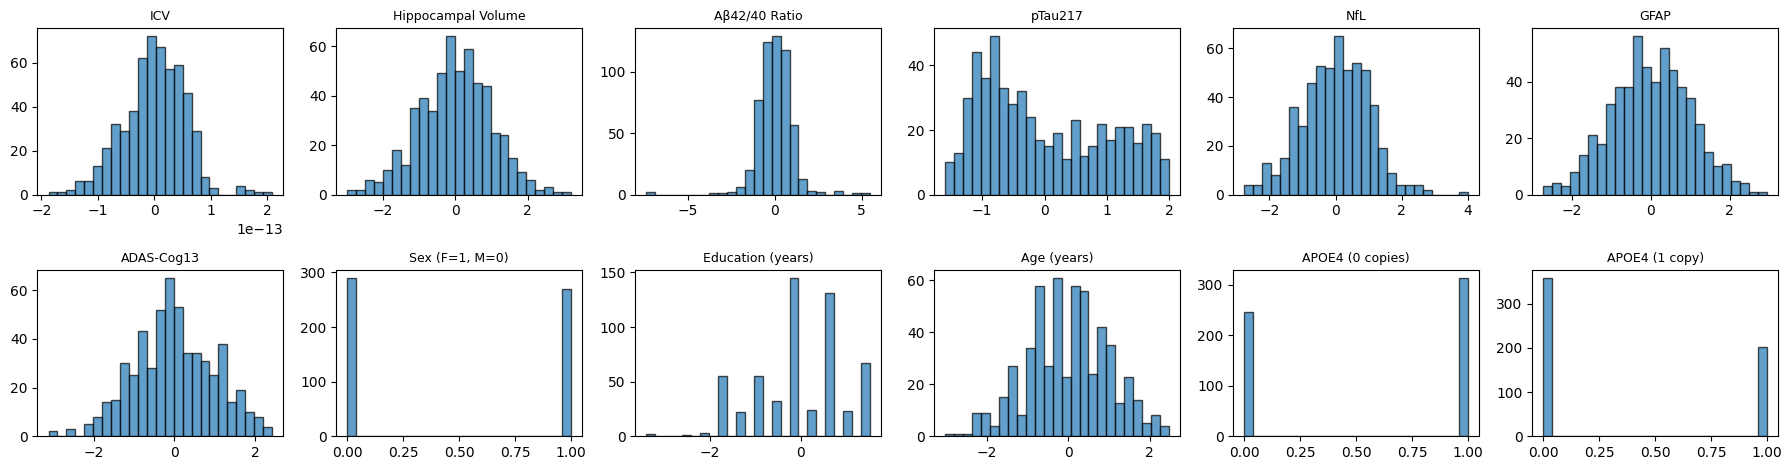

In [16]:
plot_distributions(X, setting.variables);

## 4. Background knowledge

FCI gets two kinds of prior knowledge:

- **Forbidden edges**, shown below (a dark cell means the row variable may not cause the column variable). Demographics are exogenous, so nothing may point into them. Cognitive scores are downstream, so they may not cause biomarkers or brain volumes. When both directions of a pair are forbidden (e.g. two demographics), the pair cannot be adjacent at all. Settings can switch on further rules: `forbid_cognition_to_cognition`, `forbid_mri_to_biomarkers` and `amyloid_tau_cascade`.
- **Restricted conditioning**: cognitive scores are never used in conditioning sets (`RestrictedCIT`). They are a common effect of most other variables, and conditioning on a common effect induces dependence between its causes.

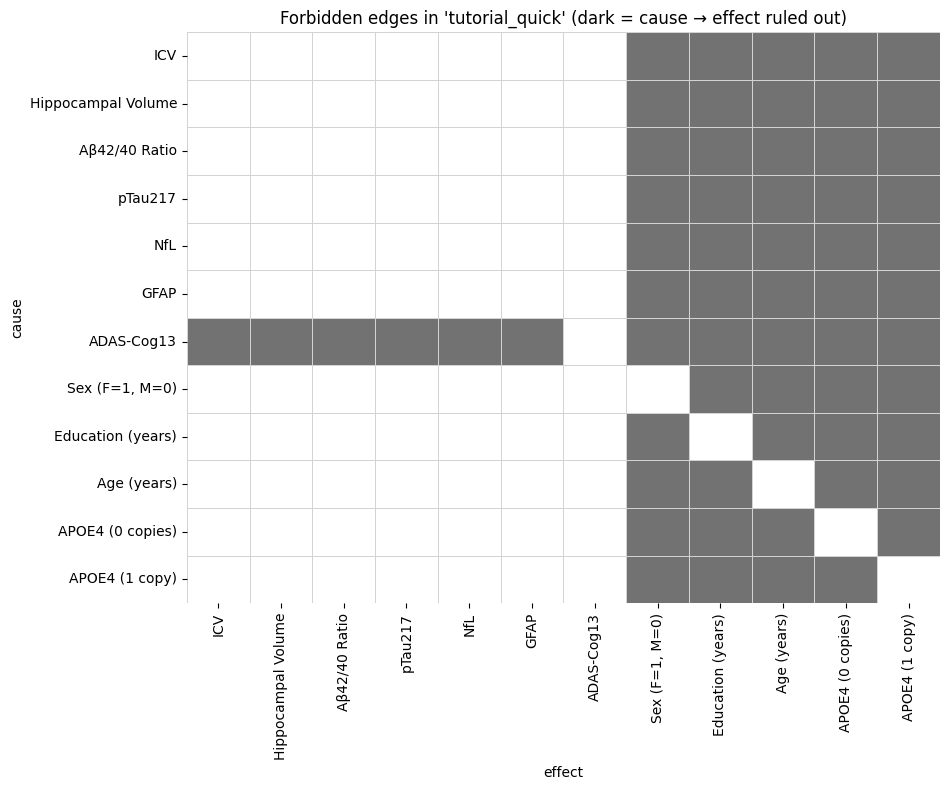

In [17]:
plot_background_knowledge(setting);

## 5. Bootstrapped FCI

Each bootstrap resamples subjects with replacement and shuffles the variable order (FCI's output can depend on it), then runs FCI with the background knowledge. Bootstrap *b* always draws from the random stream `(seed, b)`, so results do not depend on the number of workers. The alphas of the sensitivity analysis run on the same resamples and reuse the cached p-values, which makes them almost free.

FCI returns a partial ancestral graph (PAG). Its edge types mean:

In [18]:
pd.Series(EDGE_MEANINGS, name="meaning for an edge between A and B").to_frame()

,meaning for an edge between A and B
-->,"A causes B (A is an ancestor of B, B is not an ancestor of A)"
<->,neither causes the other: a latent confounder of A and B
o->,B does not cause A; A causes B and/or they share a latent confounder
o-o,"adjacent, orientation undetermined"


In [ ]:
alphas = [setting.alpha, *setting.sensitivity_alphas]
boot = run_bootstrap_fci(X, setting.variables, setting, alphas=alphas, n_jobs=N_JOBS)
boot.pags[setting.alpha].shape  # (bootstraps, variables, variables)

tutorial_quick: 100%|██████████| 28/28 [00:02<00:00, 12.39boot/s]


(28, 12, 12)

## 6. Edge frequencies

For every pair of variables and every edge type, the share of bootstraps in which FCI returned that edge. `p_adjacent` is the share with any edge between the pair. Edges are written left to right, so `A <-- B` appears as `B --> A`.

In [20]:
edges = edge_frequencies(boot.pags[setting.alpha], setting.variables)
edges.head(15)

,source,edge,target,count,probability,p_adjacent
0,PTGENDER,-->,Intracranial Volume,28,1.000000,1.000000
1,Hippocampus,-->,TOTAL13,28,1.000000,1.000000
2,AGE,-->,Hippocampus,28,1.000000,1.000000
3,pT217_F,-->,TOTAL13,28,1.000000,1.000000
4,APOE4_0,-->,pT217_F,28,1.000000,1.000000
5,AGE,-->,NfL_Q,28,1.000000,1.000000
6,PTGENDER,-->,TOTAL13,28,1.000000,1.000000
7,APOE4_0,-->,AB42_AB40_ratio,26,0.928571,0.928571
8,PTEDUCAT,-->,TOTAL13,26,0.928571,0.928571
9,NfL_Q,-->,pT217_F,23,0.821429,0.892857


In [21]:
print(f"Stable edges (frequency >= {setting.stable_edge_prob}):")
print(format_edges(edges, setting.stable_edge_prob))

Stable edges (frequency >= 0.5):
  PTGENDER             -->  Intracranial Volume  1.00
  Hippocampus          -->  TOTAL13              1.00
  AGE                  -->  Hippocampus          1.00
  pT217_F              -->  TOTAL13              1.00
  APOE4_0              -->  pT217_F              1.00
  AGE                  -->  NfL_Q                1.00
  PTGENDER             -->  TOTAL13              1.00
  APOE4_0              -->  AB42_AB40_ratio      0.93
  PTEDUCAT             -->  TOTAL13              0.93
  NfL_Q                -->  pT217_F              0.82
  Intracranial Volume  <->  Hippocampus          0.71
  NfL_Q                -->  GFAP_Q               0.54
  pT217_F              -->  AB42_AB40_ratio      0.50
  pT217_F              -->  Hippocampus          0.50


### PAG figures

Line width and labels show the bootstrap frequency. As in the abstract, the first figure hides edges below 0.1 (`min_edge_prob`) and the second shows only stable edges, ≥ 0.5 (`stable_edge_prob`).

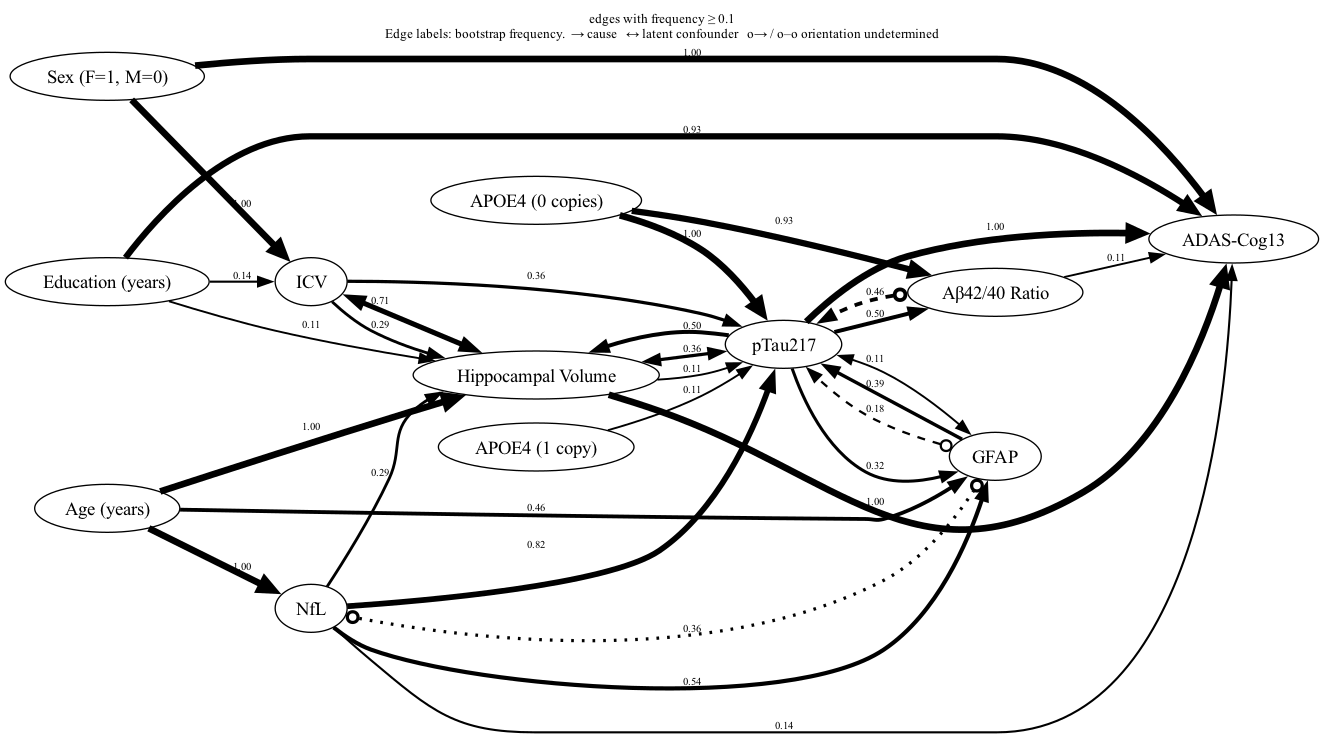

In [22]:
show_pag(edges, columns=setting.variables, min_prob=setting.min_edge_prob)

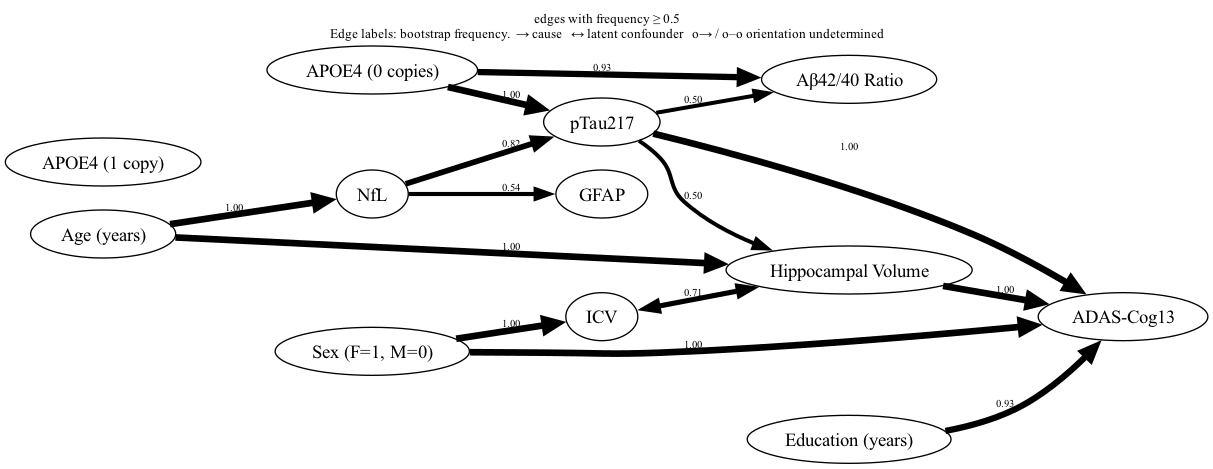

In [23]:
show_pag(edges, columns=setting.variables, min_prob=setting.stable_edge_prob)

The same information per endpoint: each cell is the probability that the edge between the row and column variables has an arrowhead, tail or circle at the **column** variable.

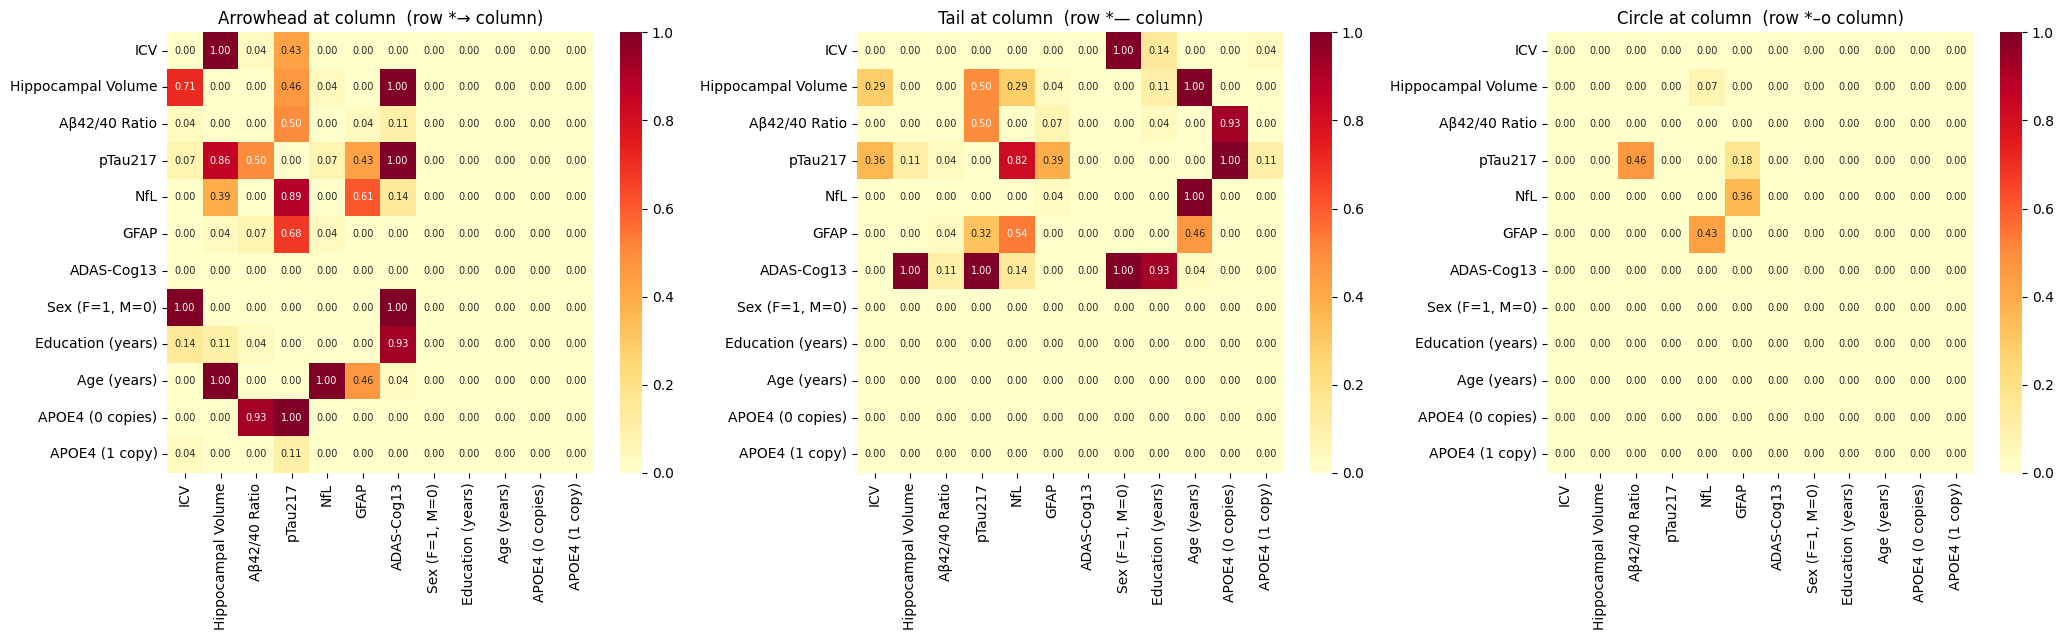

In [24]:
plot_endpoint_heatmaps(boot.pags[setting.alpha], setting.variables);

## 7. Sensitivity to α

Edge frequencies at each α, on the same resamples. Edges that hold across α are the most trustworthy.

In [25]:
sensitivity = compare_edge_tables(
    {f"alpha={a:g}": edge_frequencies(boot.pags[a], setting.variables) for a in sorted(boot.pags)}, min_prob=0.3)
sensitivity.round(2)

,,,alpha=0.01,alpha=0.05,alpha=0.1
source,edge,target,,,
PTGENDER,-->,Intracranial Volume,1.00,1.00,1.00
AGE,-->,Hippocampus,1.00,1.00,1.00
pT217_F,-->,TOTAL13,1.00,1.00,1.00
APOE4_0,-->,pT217_F,1.00,1.00,1.00
AGE,-->,NfL_Q,1.00,1.00,1.00
PTGENDER,-->,TOTAL13,0.96,1.00,0.96
Hippocampus,-->,TOTAL13,1.00,1.00,1.00
APOE4_0,-->,AB42_AB40_ratio,0.82,0.93,0.96
PTEDUCAT,-->,TOTAL13,0.64,0.93,0.96


## 8. Separating sets: biomarkers vs hippocampal volume

When FCI finds a biomarker and hippocampal volume non-adjacent, its *separating set* holds the variables that made them conditionally independent. These are candidate mediators or confounders of the association. `p_separated` is how often the pair was separated; the other columns give, when separated, how often each variable was in the separating set. Cognitive scores never appear because they are never conditioned on.

In [26]:
seps = sepset_summary(boot.sepsets[setting.alpha], setting.variables, setting.biomarkers, setting.sepset_target)
seps.round(2)

,p_separated,Intracranial Volume,AB42_AB40_ratio,pT217_F,NfL_Q,GFAP_Q,TOTAL13,PTGENDER,PTEDUCAT,AGE,APOE4_0,APOE4_1
biomarker,,,,,,,,,,,,
AB42_AB40_ratio,1.00,0.00,NaN,0.89,0.61,0.71,0.0,0.0,0.00,0.18,0.14,0.07
pT217_F,0.04,0.00,0.0,NaN,1.00,1.00,0.0,0.0,0.00,0.00,1.00,0.00
NfL_Q,0.61,0.00,0.0,1.00,NaN,0.53,0.0,0.0,0.06,1.00,0.00,0.00
GFAP_Q,0.96,0.19,0.0,0.96,0.93,NaN,0.0,0.0,0.00,0.85,0.04,0.00


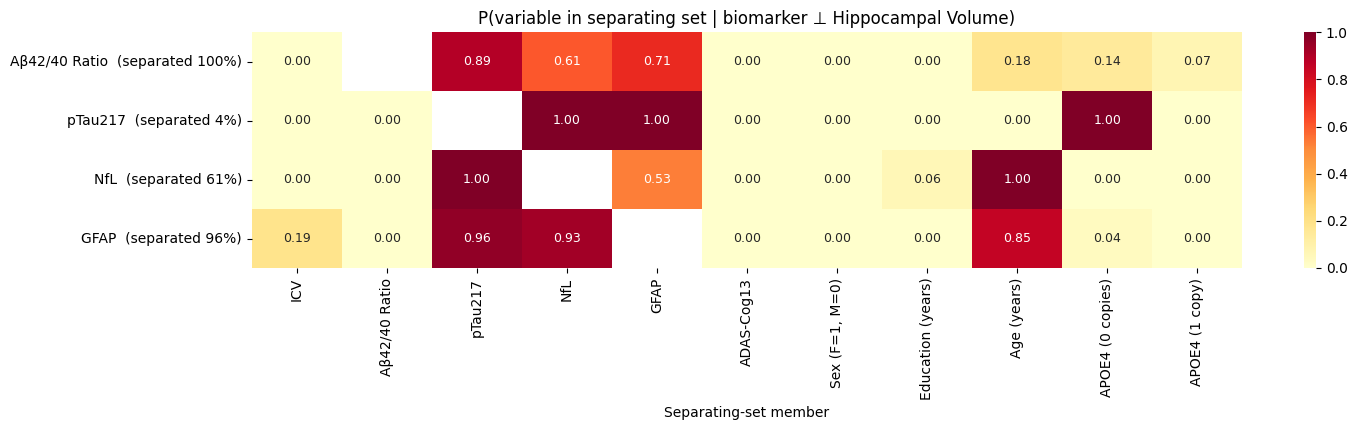

In [27]:
plot_sepsets(seps, setting.sepset_target);

## 10. The whole pipeline in one call

`run_setting` runs all of the above for a setting and writes the cohort, edge frequencies, PAG figures, heatmaps, sensitivity table, separating sets and stratified results to `results/<setting>/`. The command line calls the same function:

```bash
python run_analysis.py --list                          # available settings
python run_analysis.py main                            # full main analysis
python run_analysis.py main csf tau_pet --steps main   # only the main step, for three settings
python run_analysis.py all --n-bootstraps 50           # quick pass over every setting -> results/<name>_B50/
```

Finished runs can be reloaded with `load_results(name)`, e.g. to re-plot with other thresholds without re-running FCI, and compared with `compare_settings`. As a demonstration, three settings are run below with the Fisher-z test, which takes seconds. For real comparisons, run the KCI presets from the command line.

In [20]:
for name in ["main", "tau_pet", "csf"]:
    demo = replace(PRESETS[name], name=f"{name}_fisherz_demo", ci_test="fisherz", n_bootstraps=100)
    run_setting(demo, steps=["main"], n_jobs=N_JOBS, progress=False)


[main_fisherz_demo] Plasma Aβ42/40, pTau217, NfL, GFAP + ICV and hippocampus + ADAS-Cog13 + demographics, KCI test (AAIC abstract).
Cohort: 560 subjects {'CN': 295, 'MCI': 196, 'AD': 69}, 12 variables
CI test: fisherz, alpha = 0.05, 100 bootstraps

Stable edges (frequency >= 0.5):
  PTGENDER             -->  Intracranial Volume  1.00
  Hippocampus          -->  TOTAL13              1.00
  AGE                  -->  Hippocampus          1.00
  pT217_F              -->  TOTAL13              1.00
  APOE4_0              -->  pT217_F              1.00
  AGE                  -->  NfL_Q                1.00
  PTGENDER             -->  TOTAL13              1.00
  PTEDUCAT             -->  TOTAL13              0.93
  APOE4_0              -->  AB42_AB40_ratio      0.91
  NfL_Q                -->  pT217_F              0.86
  Intracranial Volume  <->  Hippocampus          0.76
  pT217_F              -->  Hippocampus          0.64
  NfL_Q                -->  GFAP_Q               0.57
  AGE          

In [21]:
compare_settings(["main_fisherz_demo", "tau_pet_fisherz_demo", "csf_fisherz_demo"], min_prob=0.5).round(2)

main_fisherz_demo  tau_pet_fisherz_demo  csf_fisherz_demo
source                edge target                                                                          
PTGENDER              -->  Intracranial Volume                 1.00                  1.00              1.00
                           TOTAL13                             1.00                  0.35              0.95
Hippocampus           -->  TOTAL13                             1.00                  1.00              1.00
APOE4_0               -->  ABETA42_ABETA40_ratio               0.00                  0.00              1.00
                           AB42_AB40_ratio                     0.91                  1.00              0.00
APOE4_1               -->  ABETA42_ABETA40_ratio               0.00                  0.00              1.00
AGE                   -->  NfL_Q                               1.00                  1.00              0.00
APOE4_0               -->  pT217_F                             1.00                  0.00              0.00
pT217_F               -->  TOTAL13                             1.00                  0.00              0.00
AGE                   -->  Hippocampus                         1.00                  0.95              0.99
META_TEMPORAL_SUVR    -->  TOTAL13                             0.00                  0.98              0.00
PTEDUCAT              -->  TOTAL13                             0.93                  0.95              0.96
NfL_Q                 -->  pT217_F                             0.86                  0.00              0.00
PTAU                  -->  TOTAL13                             0.00                  0.00              0.81
ABETA42_ABETA40_ratio -->  PTAU                                0.00                  0.00              0.79
Intracranial Volume   <->  Hippocampus                         0.76                  0.53              0.48
AGE                   -->  ABETA42_ABETA40_ratio               0.00                  0.00              0.70
META_TEMPORAL_SUVR    -->  Hippocampus                         0.00                  0.69              0.00
NfL_Q                 -->  GFAP_Q                              0.57                  0.68              0.00
pT217_F               -->  Hippocampus                         0.64                  0.00              0.00
AGE                   -->  PTAU                                0.00                  0.00              0.57
AB42_AB40_ratio       -->  META_TEMPORAL_SUVR                  0.00                  0.51              0.00
Intracranial Volume   -->  Hippocampus                         0.24                  0.47              0.51
AGE                   -->  GFAP_Q                              0.50                  0.24              0.00

## 11. Adding a setting

Add an entry to `PRESETS` in `adni_fci/settings.py`, derived from an existing setting:

```python
replace(MAIN, name="amyloid_cascade", amyloid_tau_cascade=True,
        description="Main setting with NfL/GFAP forbidden from causing amyloid/tau markers."),
```

It is then available everywhere: `python run_analysis.py amyloid_cascade`, `PRESETS["amyloid_cascade"]` in this notebook, and `--list`. Biomarker and cognitive variables must be ones that `adni_fci/data.py` knows how to load. MRI variables can be any region of the FreeSurfer dictionary, e.g. `"Entorhinal Cortex"`.